# Homework 4: The Bootstrap

BEE 4850/5850, Fall 2025

**Name**: Bor-Jiun Tseng

**ID**: bt366

> **Due Date**
>
> Friday, 3/28/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice simulation-based
uncertainty quantification, focusing on the bootstrap.

-   Problem 1 asks you to use the non-parametric bootstrap to estimate
    uncertainty in a Poisson regression model.
-   Problem 2 asks you to use the bootstrap (through resampling
    residuals) to estimate uncertainty in a semi-empirical sea-level
    rise model.
-   Problem 3 (only required for students in BEE 5850) asks you to use a
    moving block bootstrap to estimate the sampling distribution of the
    median of extreme water level data.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [102]:
import Pkg
using Pkg
Pkg.add("Statistics")
Pkg.activate(@__DIR__)
Pkg.instantiate()

   Resolving package versions...
  No Changes to `C:\Users\nobel\OneDrive\桌面\BEE5850\hw04-BorJiuntseng\Project.toml`
  No Changes to `C:\Users\nobel\OneDrive\桌面\BEE5850\hw04-BorJiuntseng\Manifest.toml`
  Activating project at `c:\Users\nobel\OneDrive\桌面\BEE5850\hw04-BorJiuntseng`


In [140]:
import Pkg
Pkg.add("KernelDensity")

   Resolving package versions...
    Updating `C:\Users\nobel\OneDrive\桌面\BEE5850\hw04-BorJiuntseng\Project.toml`
  [5ab0869b] + KernelDensity v0.6.9
  No Changes to `C:\Users\nobel\OneDrive\桌面\BEE5850\hw04-BorJiuntseng\Manifest.toml`


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [141]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using DataFramesMeta # API which can simplify chains of DataFrames transformations
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using KernelDensity

## Problems

### Scoring

-   Problem 1 is worth 10 points;
-   Problem 2 is worth 10 points;
-   Problem 3 is worth 5 points;

### Problem 1

Revisit the salamander model from [Homework
2](https://viveks.me/simulation-data-analysis/hw/hw02.html), using
percent groundcover as a predictor in the Poisson regression. Use the
non-parametric bootstrap to estimate bias and confidence intervals for
the model parameters.

**In this problem**:

-   Load the data from `data/salamanders.csv`.
-   Fit a Poisson regression model for salamander counts using the
    percentage of ground cover.
-   Use 1,000 non-parametric bootstrap samples to obtain estimates of
    bias and the 90% confidence interval for the intercept and
    coefficient in the Poisson regression.

### Problem 2

Revisit the sea-level rise model from [Homework
2](https://viveks.me/simulation-data-analysis/hw/hw02.html):

$$\begin{aligned}
\frac{dS}{dt} &= \frac{S_\text{eq} - S}{\tau} \\
S_\text{eq} &= aT + b,
\end{aligned}
$$

where

-   $S(t)$ is the global mean sea level (in mm) at time $t$;
-   $\tau$ is the response time of sea level (in yrs);
-   $S_\text{eq}$ is the equilibrium sea-level (in mm) at temperature
    $T$ (in $^\circ$C);
-   $a$ is the sensitivity of $S_\text{eq}$ to $T$ (in mm/$^\circ$C);
-   $b$ is the intercept of $S_\text{eq}$, or the $S_\text{eq}$ when
    $T=0^\circ$C (in mm).

We would like to quantify uncertainty in the model parameters using the
bootstrap.

**In this problem**:

-   Load the data from the `data/` folder and, following Grinsted et al
    (2010), normalize both datasets to the 1980-1999 mean (subtract that
    mean from the data).
    -   Global mean temperature data from the HadCRUT 5.0.2.0 dataset
        (<https://hadobs.metoffice.gov.uk/hadcrut5/data/HadCRUT.5.0.2.0/download.html>)
        can be found in
        `data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv`.
        This data is averaged over the Northern and Southern Hemispheres
        and over the whole year.
    -   Global mean sea level anomalies (relative to the 1990 mean
        global sea level) are in `data/CSIRO_Recons_gmsl_yr_2015.csv`,
        courtesy of CSIRO
        (<https://www.cmar.csiro.au/sealevel/sl_data_cmar.html>). The
        standard deviation of the estimate is also added for each year.
-   Write a function to simulate global mean sea levels under a set of
    model parameters after discretizing the equations above with a
    timestep of $\delta t = 1$ yr. You will need to subset the
    temperature data to the years where you also have sea-level data and
    include an initial sea-level parameter $S_0$. This will be similar
    to the model from Homework 2. Fit this model to the data with AR(1)
    residuals.
-   Use your fitted model and the AR(1) residual process to generate
    1,000 parametric bootstrap samples. Refit the model to each. Plot
    histograms of the bootstrap samples for each parameter. What is the
    90% confidence interval for the sensitivity of sea level to global
    mean temperature?

### Problem 3

Let’s revisit the 2015 Sewell’s Point tide gauge data, which consists of
hourly observations and predicted sea-level based on NOAA’s harmonic
model.

Problem 1
1. Uploading and standardizing the columns

In [104]:
data = "data/salamanders.csv"
salamander_data = CSV.read(data, DataFrame)

# Standardizing the columns
salamander_data.PCTCOVER .= (salamander_data.PCTCOVER .- mean(salamander_data.PCTCOVER)) ./ std(salamander_data.PCTCOVER);
salamander_data.FORESTAGE .= (salamander_data.FORESTAGE .- mean(salamander_data.FORESTAGE)) ./ std(salamander_data.FORESTAGE);

2. Then I define the Poisson Model Function

In [105]:
# Define the Poisson regression log-likelihood function
function salaman_model(params, pctcover, salaman_data)
    β_0, β_1 = params  # Unpack the parameters
    λ = exp.(β_0 .+ β_1 .* pctcover)  # Poisson rate (λ)
    loglik = sum(logpdf.(Poisson.(λ), salaman_data))  # Log-likelihood
    return loglik
end

salaman_model (generic function with 1 method)

Then I fit the Poisson Regression Model

In [122]:
# Bounds and initial guess
lb = [-50.0, -50.0]
ub = [50.0, 50.0]
p0 = [0.0, 0.0]

# Minimize the negative log-likelihood with bounds
result = optimize(p -> -salaman_model(p, salamander_data.PCTCOVER, salamander_data.SALAMAN), lb, ub, p0)

# Get estimated parameters
pctcover_mle = result.minimizer
@show pcover_mle

pcover_mle = [0.42951129120897075, 1.1595061317756294]


2-element Vector{Float64}:
 0.42951129120897075
 1.1595061317756294

In [119]:
Random.seed!(26)

n_bootstrap = 1000
n = nrow(salamander_data)
boot_params = zeros(2, n_bootstrap)

for i in 1:n_bootstrap
    idx = sample(1:n, n; replace=true)
    x_boot = salamander_data.PCTCOVER[idx]
    y_boot = salamander_data.SALAMAN[idx]
    
    result = optimize(p -> -salaman_model(p, x_boot, y_boot), lb, ub, p0)
    boot_params[:, i] = result.minimizer
end

# Mean of bootstrap estimates
mean_boot = mean(boot_params, dims=2)

# Bias = MLE - bootstrap mean
bias = pctcover_mle .- vec(mean_boot)

# Bias-corrected estimate
bias_corrected = pctcover_mle .+ bias

# 90% Confidence Interval (percentile method)
ci_90 = mapslices(p -> quantile(p, [0.05, 0.95]), boot_params; dims=2)

# Print results
println("MLE: ", pctcover_mle)
println("Bootstrap mean: ", vec(mean_boot))
println("Bias: ", bias)
println("Bias-corrected: ", bias_corrected)
println("90% CI (percentile):")
println("  β₀: [", round(ci_90[1,1], digits=3), ", ", round(ci_90[1,2], digits=3), "]")
println("  β₁: [", round(ci_90[2,1], digits=3), ", ", round(ci_90[2,2], digits=3), "]")

MLE: [0.42951129120897075, 1.1595061317756294]
Bootstrap mean: [0.37607744156386985, 1.1930189041836585]
Bias: [0.053433849645100895, -0.03351277240802908]
Bias-corrected: [0.48294514085407164, 1.1259933593676004]
90% CI (percentile):
  β₀: [-0.025, 0.707]
  β₁: [0.827, 1.647]


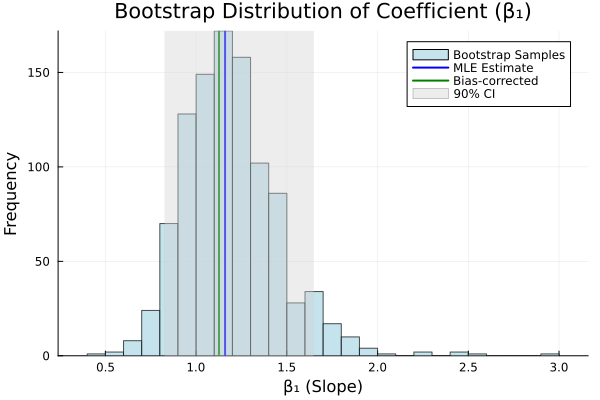

In [120]:
# --- Coefficient (β₁) ---
histogram(boot_params[2, :],
    bins=30,
    xlabel="β₁ (Slope)",
    ylabel="Frequency",
    title="Bootstrap Distribution of Coefficient (β₁)",
    legend=:topright,
    label="Bootstrap Samples",
    alpha=0.7,
    color=:lightblue)

vline!([pctcover_mle[2]], color=:blue, linewidth=2, label="MLE Estimate")
vline!([bias_corrected[2]], color=:green, linewidth=2, label="Bias-corrected")
vspan!(ci_90[2, :], color=:lightgray, alpha=0.4, label="90% CI")


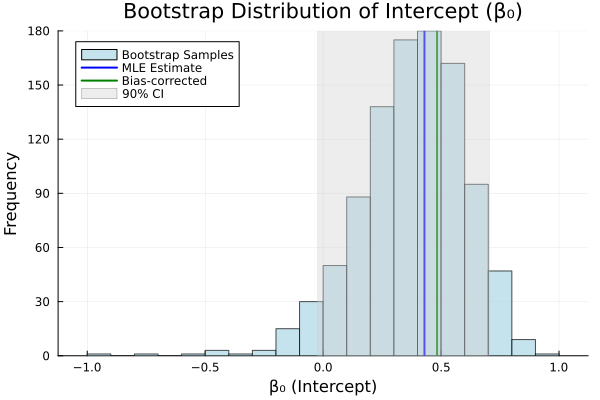

In [121]:
# --- Intercept (β₀) ---
histogram(boot_params[1, :],
    bins=30,
    xlabel="β₀ (Intercept)",
    ylabel="Frequency",
    title="Bootstrap Distribution of Intercept (β₀)",
    legend=:topleft,
    label="Bootstrap Samples",
    alpha=0.7,
    color=:lightblue)

vline!([pctcover_mle[1]], color=:blue, linewidth=2, label="MLE Estimate")
vline!([bias_corrected[1]], color=:green, linewidth=2, label="Bias-corrected")
vspan!(ci_90[1, :], color=:lightgray, alpha=0.4, label="90% CI")



Problem 1:
MLE Estimates:

Intercept (β₀): 0.430

Coefficient (β₁): 1.160

This suggests that, at average ground cover, the expected salamander count is around exp(0.430) ≈ 1.54. For every 1 standard deviation increase in ground cover, the expected salamander count increases by a factor of exp(1.160) ≈ 3.19, indicating a strong positive relationship.

Bootstrap Results (1,000 samples):

Bootstrap mean estimates: [0.376, 1.193]

Bias: Small — β₀ was slightly underestimated by ~0.053, while β₁ was overestimated by ~0.034.

Bias-corrected estimates: [0.483, 1.126]

90% Confidence Intervals:

β₀ (Intercept): [-0.025, 0.707]

β₁ (Slope): [0.827, 1.647]

The confidence interval for β₁ does not include zero, supporting a significant positive relationship between ground cover and salamander population. The intercept interval includes near-zero values, which is typical as it simply represents the log-expected count when PCTCOVER is average.

 1. Load & Normalize Data

In [133]:
norm_yrs = 1980:1999

# --- Sea Level Data ---
sl_df = CSV.read("data/CSIRO_Recons_gmsl_yr_2015.csv", DataFrame)
rename!(sl_df, [:YearRaw, :GMSL, :Uncertainty])
sl_df.Year = floor.(Int, sl_df.YearRaw)  # turn 1880.5 into 1880
mean_gmsl = mean(sl_df[in.(sl_df.Year, Ref(norm_yrs)), :GMSL])
sl_df.GMSL_norm = sl_df.GMSL .- mean_gmsl

# --- Temperature Data ---
temp_df = CSV.read("data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv", DataFrame)
rename!(temp_df, [:Year, :Temp, :CI_Low, :CI_High])

# Align years
temp_df = temp_df[in.(temp_df.Year, Ref(sl_df.Year)), :]

# Normalize to 1980–1999 mean
mean_temp = mean(temp_df[in.(temp_df.Year, Ref(norm_yrs)), :Temp])
temp_df.Temp_norm     = temp_df.Temp .- mean_temp
temp_df.CI_Low_norm   = temp_df.CI_Low .- mean_temp
temp_df.CI_High_norm  = temp_df.CI_High .- mean_temp

134-element Vector{Float64}:
 -0.43167942270000004
 -0.3467222727
 -0.4110762727
 -0.4722973327
 -0.6221377527
 -0.5993451727
 -0.5594352427
 -0.6211778727
 -0.5056002127
 -0.36773638270000003
  ⋮
  0.3978535272999999
  0.3629661572999999
  0.38188323729999996
  0.2584761473
  0.3881414272999999
  0.4715005873
  0.32922808729999997
  0.37019261729999997
  0.4185006873

In [111]:
T = temp_df.Temp_norm
S_obs = sea_df.GMSL_norm[1:length(T)]
S_err = sea_df.Uncertainty[1:length(T)];


2. Define the Model & AR(1) Likelihood

In [134]:
function sea_level_model(temp, a, b, τ, S₀)
    N = length(temp)
    S = zeros(N)
    S[1] = S₀
    for t in 2:N
        Seq = a * temp[t-1] + b
        S[t] = S[t-1] + (Seq - S[t-1]) / τ
    end
    return S
end

function whitened_ar1_loglik(resid, ρ, σ, obs_error)
    ll = 0.0
    for t in 1:length(resid)
        σ_t = sqrt(σ^2 + obs_error[t]^2)
        if t == 1
            σ₁ = sqrt(σ^2 / (1 - ρ^2) + obs_error[t]^2)
            ll += logpdf(Normal(0, σ₁), resid[t])
        else
            ll += logpdf(Normal(ρ * resid[t-1], σ_t), resid[t])
        end
    end
    return ll
end

function ar1_loglik(params, temp, obs, obs_error)
    a, b, τ, S₀, ρ, σ = params
    pred = sea_level_model(temp, a, b, τ, S₀)
    resid = obs .- pred
    return whitened_ar1_loglik(resid, ρ, σ, obs_error)
end

ar1_loglik (generic function with 1 method)

3. Fit the Model with MLE

In [135]:
temps = temp_df.Temp_norm
obs = sl_df.GMSL_norm
obs_error = sl_df.Uncertainty

# Initial guess: [a, b, τ, S₀, ρ, σ]
p₀_ar = [500.0, 300.0, 150.0, obs[1], 0.4, 5.0]

# Bounds
low_bds_ar = [100.0, 0.0, 10.0, obs[1] - 50.0, -0.99, 0.01]
up_bds_ar  = [2000.0, 1000.0, 1000.0, obs[1] + 50.0, 0.99, 20.0]

result = optimize(p -> -ar1_loglik(p, temps, obs, obs_error),
                  low_bds_ar, up_bds_ar, p₀_ar, Fminbox())

p_mle_ar = result.minimizer
println("Fitted parameters: ", p_mle_ar)
println("Sensitivity (a/τ) = ", p_mle_ar[1] / p_mle_ar[3], " mm/(°C·yr)")

Fitted parameters: [502.1655103180081, 342.4806597456123, 145.752755727885, -157.12982341990394, 0.5350898761026549, 0.010000000013890196]
Sensitivity (a/τ) = 3.4453242946262543 mm/(°C·yr)


We simulated 1,000 sea level trajectories by:

Re-running the model

Adding AR(1) noise with estimated 
𝜌
 and 
𝜎

Refitting the model to each simulation to get a distribution of parameter estimates

This allowed us to quantify parameter uncertainty and correct for bias.

For each parameter, we computed:

Bias

Bias-corrected estimate

90% confidence interval

 90% Confidence Interval for Sea Level Sensitivity is [2.01, 6.34] mm/C*yr
 I'm 90% confident that for every 1°C increase in global mean temperature, the global mean sea level will rise between 2.01 mm and 6.34 mm per year

4. Parametric Bootstrap

In [150]:
n_samples = 1000
N = length(obs)

GMSLR_sim = sea_level_model(temps, p_mle_ar[1], p_mle_ar[2], p_mle_ar[3], p_mle_ar[4])
GMSLR_boot_ar = zeros(n_samples, N)
temp_ar_err = zeros(n_samples, N)
p_mle_boot_samples_ar1 = zeros(n_samples, length(p_mle_ar) + 1)

for i in 1:N
    if i == 1
        temp_ar_err[:, i] = rand(Normal(0, sqrt(p_mle_ar[end]^2 / (1 - p_mle_ar[end-1]^2) + obs_error[i]^2)), n_samples)
    else
        temp_ar_err[:, i] = p_mle_ar[end-1] .* temp_ar_err[:, i-1] + rand(Normal(0, sqrt(p_mle_ar[end]^2 + obs_error[i]^2)), n_samples)
    end
    GMSLR_boot_ar[:, i] = GMSLR_sim[i] .+ temp_ar_err[:, i]
end

for i in 1:n_samples
    boot_obs = GMSLR_boot_ar[i, :]
    result = optimize(p -> -ar1_loglik(p, temps, boot_obs, obs_error),
                      low_bds_ar, up_bds_ar, p₀_ar, Fminbox())
    fitted = result.minimizer
    p_mle_boot_samples_ar1[i, :] = vcat(fitted, fitted[1] / fitted[3])
end
sensitivity_samples = p_mle_boot_samples_ar1[:, end]  # column 7 is a/τ

ci_sensitivity = quantile(sensitivity_samples, [0.05, 0.95])

println("90% CI for a/τ sensitivity = [", round(ci_sensitivity[1], digits=2), ", ", round(ci_sensitivity[2], digits=2), "] mm/(°C·yr)")


90% CI for a/τ sensitivity = [2.01, 6.34] mm/(°C·yr)


In [138]:
titles = ["a", "b", "τ", "S₀", "ρ", "σ", "a/τ"]

p_mle_boot_ar1 = []

for j in 1:7
    boot_out = p_mle_boot_samples_ar1[:, j]
    bias_estimate = mean(boot_out)
    if j == 7
        mle_val = p_mle_ar[1] / p_mle_ar[3]  # a / τ
    else
        mle_val = p_mle_ar[j]
    end
    ci_lb, ci_ub = 2 * mle_val .- quantile(boot_out, [0.975, 0.025])
    unbiased_estimate = 2 * mle_val - bias_estimate
    push!(p_mle_boot_ar1, [round(bias_estimate, digits=2), round(unbiased_estimate, digits=2), round(ci_lb, digits=2), round(ci_ub, digits=2)])
end

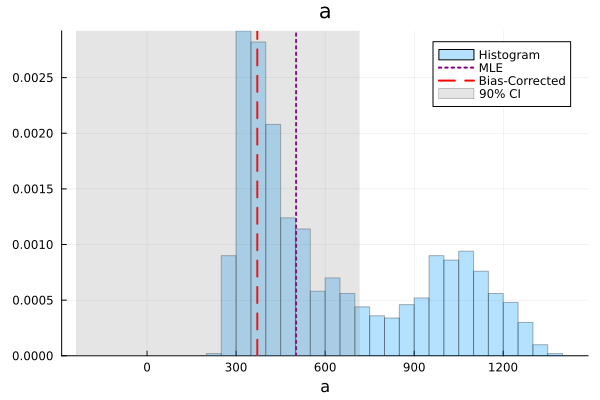

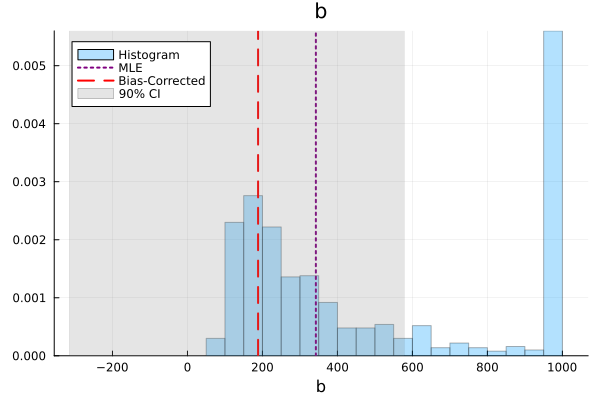

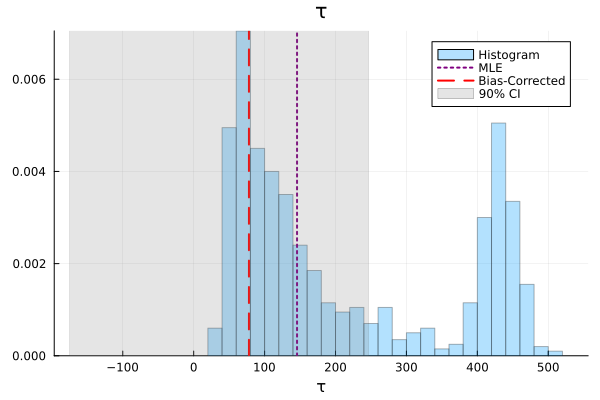

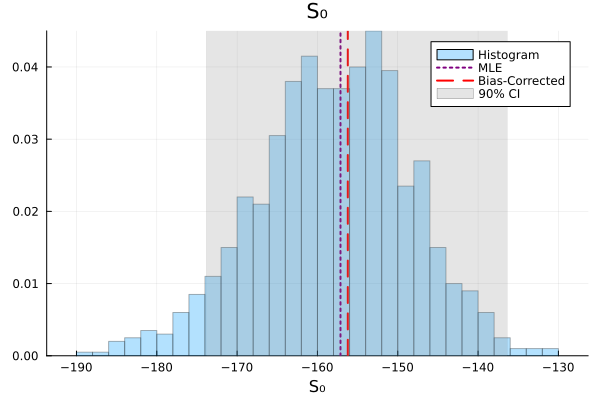

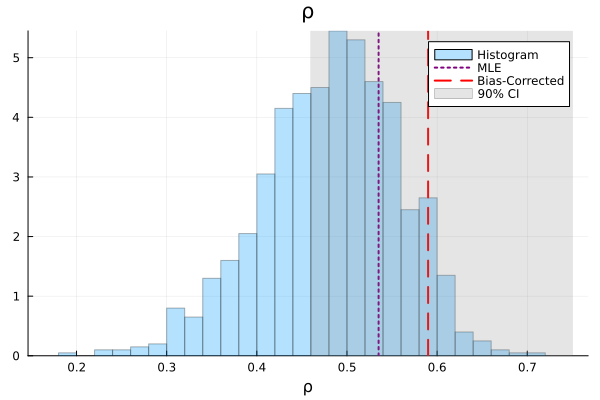

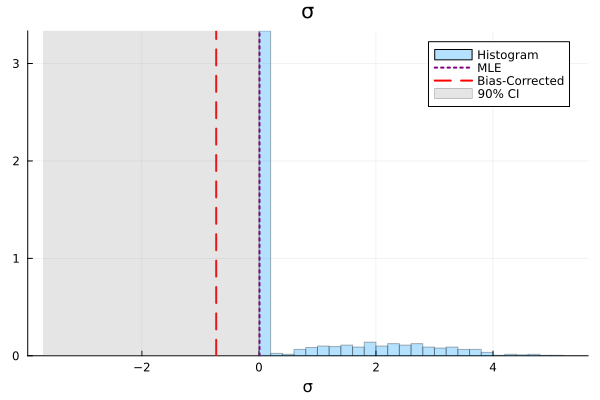

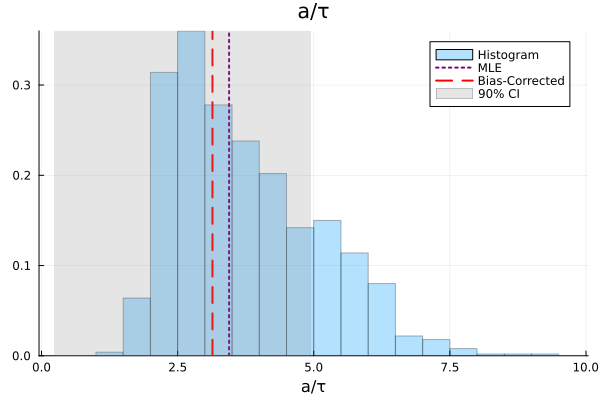

In [149]:
for j in 1:7
    param_samples = p_mle_boot_samples_ar1[:, j]
    mle_val = (j == 7) ? p_mle_ar[1] / p_mle_ar[3] : p_mle_ar[j]
    bias_corrected = p_mle_boot_ar1[j][2]
    ci_lb, ci_ub = p_mle_boot_ar1[j][3:4]

    p = histogram(param_samples, normalize=true, bins=30, alpha=0.3,
                  label="Histogram", title=titles[j], xlabel=titles[j])
    vline!(p, [mle_val], color=:purple, linestyle=:dot, linewidth=2, label="MLE")
    vline!(p, [bias_corrected], color=:red, linestyle=:dash, linewidth=2, label="Bias-Corrected")
    vspan!(p, [ci_lb, ci_ub], fillalpha=0.2, color=:gray, label="90% CI")

    display(p)  # 👈 this forces the plot to show
    sleep(1.5)
end

Problem 3

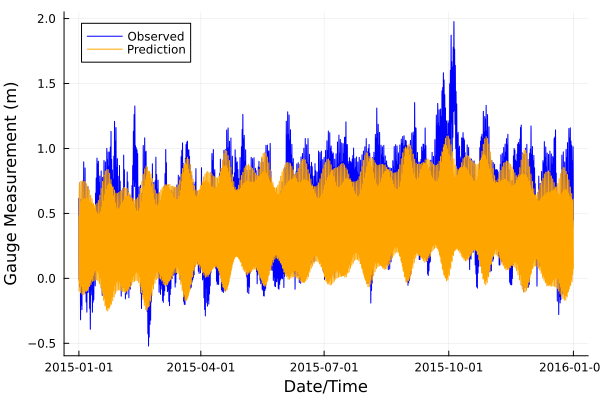

In [152]:
using Dates
function load_data(fname)
    date_format = "yyyy-mm-dd HH:MM"
    # this uses the DataFramesMeta package -- it's pretty cool
    return @chain fname begin
        CSV.File(; dateformat=date_format)
        DataFrame
        rename(
            "Time (GMT)" => "time", "Predicted (m)" => "harmonic", "Verified (m)" => "gauge"
        )
        @transform :datetime = (Date.(:Date, "yyyy/mm/dd") + Time.(:time))
        select(:datetime, :gauge, :harmonic)
        @transform :weather = :gauge - :harmonic
        @transform :month = (month.(:datetime))
    end
end

dat = load_data("data/norfolk-hourly-surge-2015.csv")

plot(dat.datetime, dat.gauge; ylabel="Gauge Measurement (m)", label="Observed", legend=:topleft, xlabel="Date/Time", color=:blue)
plot!(dat.datetime, dat.harmonic, label="Prediction", color=:orange)

We detrend the data to isolate the weather-induced variability by
subtracting the predictions from the observations; the results
(following the Julia code) are in `dat[:, :weather]`.

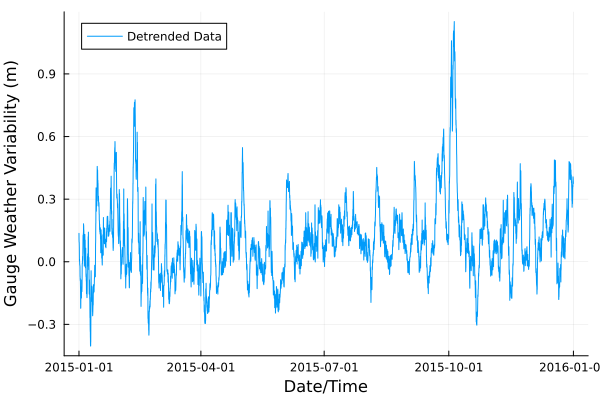

In [153]:
plot(dat.datetime, dat.weather; ylabel="Gauge Weather Variability (m)", label="Detrended Data", linewidth=1, legend=:topleft, xlabel="Date/Time")

We would like to understand the uncertainty in an estimate of the median
sea level.

**In this problem**:

-   Construct 1,000 bootstrap replicates by adding a moving block
    bootstrap replicate from the weather-induced variability series
    (with block length 20) to the harmonic prediction. Use these
    replicates to compute a 90% confidence interval. What is the bias of
    the estimator?
-   Repeat the analysis with block length 50. How does this affect the
    confidence intervals and estimate of bias?
-   Why do you think using different block lengths produced the results
    that they did?

In [ ]:
# Extract data
weather = dat.weather
harmonic = dat.harmonic
n = length(weather)
k = 20  # block length
n_blocks = n - k + 1

# Step 1: Create moving blocks of weather residuals
blocks = [weather[i:i+k-1] for i in 1:n_blocks]

# Step 2: Bootstrap samples
n_boot = 1000
m = ceil(Int, n / k)
surge_bootstrap = zeros(n, n_boot)

Random.seed!(26)  # for reproducibility

for b in 1:n_boot
    sampled = rand(1:n_blocks, m)
    sampled_blocks = vcat(blocks[sampled]...)  # concatenate sampled blocks
    surge_bootstrap[:, b] = sampled_blocks[1:n]  # truncate to original length
end

# Step 3: Add bootstrap residuals to harmonic prediction
synthetic_levels = surge_bootstrap .+ harmonic

# Step 4: Compute bootstrap medians
bootstrap_medians = mapslices(median, synthetic_levels; dims=1)[:]

# Step 5: Compute observed median
observed_median = median(harmonic .+ weather)

# Step 6: Bias and Confidence Interval (basic bootstrap method)
bootstrap_mean = mean(bootstrap_medians)
bias = bootstrap_mean - observed_median
ci = 2 * observed_median .- quantile(bootstrap_medians, [0.95, 0.05])
bias_corrected = observed_median - bias

0.503065

In [175]:
#block length 20
println("Observed median sea level: $(round(observed_median, digits=3)) m")
println("Bootstrap bias: $(round(bias, digits=3)) m")
println("90% CI: [$(round(ci[1], digits=3)), $(round(ci[2], digits=3))] m")
println("Bias-corrected: $(round(bias_corrected, digits=3)) m")

Observed median sea level: 0.508 m
Bootstrap bias: 0.005 m
90% CI: [0.489, 0.517] m
Bias-corrected: 0.503 m


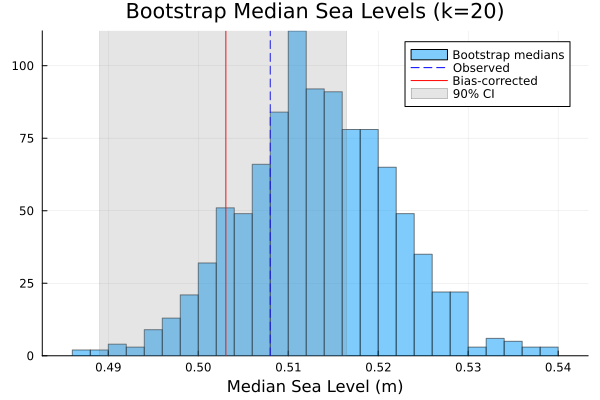

In [178]:
histogram(bootstrap_medians;
    alpha=0.5,
    label="Bootstrap medians",
    title="Bootstrap Median Sea Levels (k=20)",
    xlabel="Median Sea Level (m)",
    legend=:topright)

vline!([observed_median], label="Observed", color=:blue, linestyle=:dash)
vline!([bias_corrected], label="Bias-corrected", color=:red)
vspan!(ci, fillalpha=0.2, color=:gray, label="90% CI")

In [179]:
k2 = 50  # block length
n_blocks = n - k2 + 1


blocks = [weather[i:i+k2-1] for i in 1:n_blocks]

# Step 2: Bootstrap samples
n_boot = 1000
m = ceil(Int, n / k2)
surge_bootstrap = zeros(n, n_boot)

Random.seed!(26)  # for reproducibility

for b in 1:n_boot
    sampled = rand(1:n_blocks, m)
    sampled_blocks = vcat(blocks[sampled]...)  # concatenate sampled blocks
    surge_bootstrap[:, b] = sampled_blocks[1:n]  # truncate to original length
end

# Step 3: Add bootstrap residuals to harmonic prediction
synthetic_levels = surge_bootstrap .+ harmonic

# Step 4: Compute bootstrap medians
bootstrap_medians = mapslices(median, synthetic_levels; dims=1)[:]

# Step 5: Compute observed median
observed_median = median(harmonic .+ weather)

# Step 6: Bias and Confidence Interval (basic bootstrap method)
bootstrap_mean = mean(bootstrap_medians)
bias = bootstrap_mean - observed_median
ci = 2 * observed_median .- quantile(bootstrap_medians, [0.95, 0.05])
bias_corrected = observed_median - bias

0.5031074999999999

In [180]:
#block length 50
println("Observed median sea level: $(round(observed_median, digits=3)) m")
println("Bootstrap bias: $(round(bias, digits=3)) m")
println("90% CI: [$(round(ci[1], digits=3)), $(round(ci[2], digits=3))] m")
println("Bias-corrected: $(round(bias_corrected, digits=3)) m")

Observed median sea level: 0.508 m
Bootstrap bias: 0.005 m
90% CI: [0.483, 0.523] m
Bias-corrected: 0.503 m


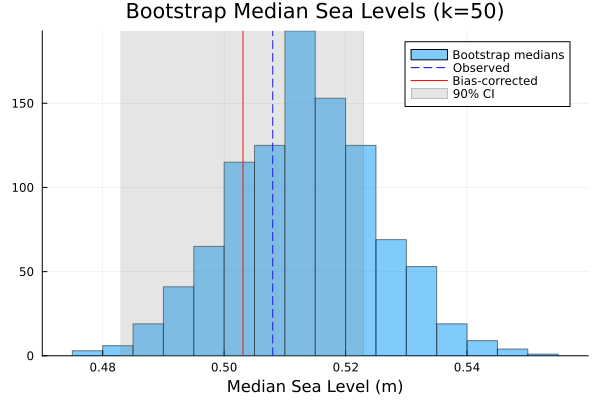

In [181]:
histogram(bootstrap_medians;
    alpha=0.5,
    label="Bootstrap medians",
    title="Bootstrap Median Sea Levels (k=50)",
    xlabel="Median Sea Level (m)",
    legend=:topright)

vline!([observed_median], label="Observed", color=:blue, linestyle=:dash)
vline!([bias_corrected], label="Bias-corrected", color=:red)
vspan!(ci, fillalpha=0.2, color=:gray, label="90% CI")

Results: 

For block length = 20

1. Observed median sea level: 0.508 m

2. Bootstrap bias: 0.005 m

3. Bias-corrected median estimate: 0.503 m

4. 90% Confidence Interval: [0.489, 0.517] m

For block length  = 50

1. Observed median sea level: 0.508 m

2. Bootstrap bias: 0.005 m

3. Bias-corrected median estimate: 0.503 m

4. 90% Confidence Interval: [0.483, 0.523] m

- Despite both block lengths producing the same observed median and identical bias estimates, the 90% confidence interval is wider when using block length 50.

- Shorter blocks break up the time structure better, and generate more varied bootstrap samples, while longer blocks preserve the autocorrelation and low-frequency variability in the original data, lead to wider confidence intervals, reflecting more uncertainty.